# SQL Analysis — BNPL Fraud Detection

This notebook demonstrates SQL skills from basic to advanced, querying a SQLite database containing Buy Now, Pay Later transaction data. We cover aggregations, JOINs, window functions, CTEs, and complex fraud analytics.

**Data quality notes:** Some `order_amount` values contain dollar signs (stored as strings like `"$123.45"`), some are negative, and some are unrealistically large. Date formats are inconsistent across tables. Some `installments` reference non-existent `plan_id`s. Queries handle these issues with `CAST`, `REPLACE`, filtering, and defensive JOINs.

## Setup

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100

DB_PATH = "../data/bnpl.db"
conn = sqlite3.connect(DB_PATH)


def query(sql: str) -> pd.DataFrame:
    """Run SQL against the BNPL database and return a DataFrame."""
    return pd.read_sql(sql, conn)


tables = query("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name")
print("Tables in database:")
for t in tables["name"]:
    cols = query(f"PRAGMA table_info({t})")
    print(f"  {t}: {', '.join(cols['name'])}")

/opt/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Tables in database:
  credit_decisions: decision_id, customer_id, order_id, decision, approved_amount, decision_timestamp, decline_reason
  customer_segments_ground_truth: customer_id, segment
  customers: customer_id, first_name, last_name, email, phone, address, city, state, zip_code, dob, signup_date, ssn_last4, annual_income, credit_score, employment_status
  device_fingerprints: fingerprint_id, customer_id, order_id, device_type, device_id, ip_address, browser, os, is_vpn, latitude, longitude
  disputes: dispute_id, order_id, dispute_reason, dispute_amount, filed_date, resolution
  installments: installment_id, plan_id, installment_number, amount_due, due_date, status, days_past_due
  merchants: merchant_id, merchant_name, category, risk_tier, onboarding_date
  order_fraud_labels: order_id, customer_id, segment, is_fraud
  orders: order_id, customer_id, merchant_id, order_amount, order_date, order_status, channel
  payment_plans: plan_id, order_id, plan_type, num_installments, ins

## Basic Queries

### Customer count by state

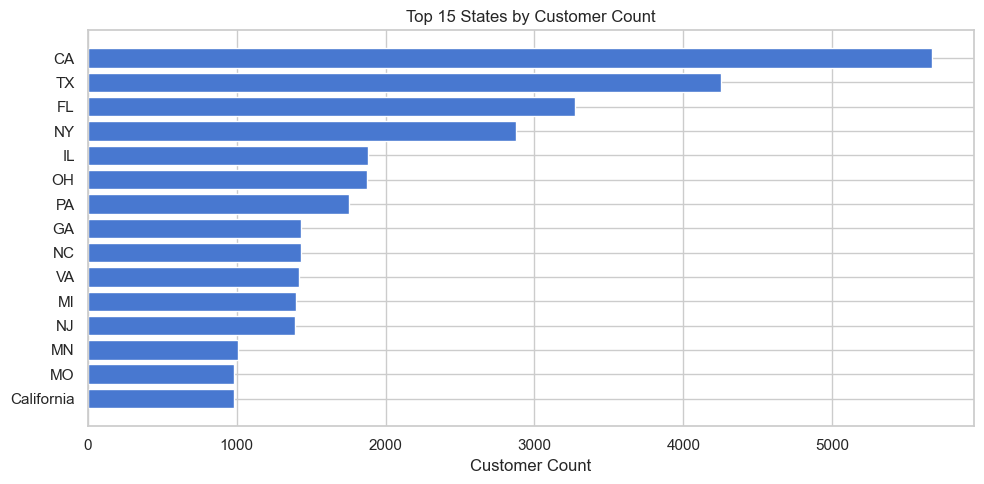

,state,customer_count
0,CA,5669
1,TX,4250
2,FL,3275
3,NY,2875
4,IL,1880
5,OH,1872
6,PA,1756
7,GA,1435
8,NC,1434
9,VA,1418


In [2]:
df_state = query("""
    SELECT state,
           COUNT(*) AS customer_count
    FROM   customers
    WHERE  state IS NOT NULL
    GROUP  BY state
    ORDER  BY customer_count DESC
    LIMIT  15
""")

fig, ax = plt.subplots()
ax.barh(df_state["state"][::-1], df_state["customer_count"][::-1])
ax.set_xlabel("Customer Count")
ax.set_title("Top 15 States by Customer Count")
plt.tight_layout()
plt.show()

df_state

### Order volume and GMV by month

We clean `order_amount` by stripping dollar signs and casting to a numeric type. Negative and absurdly large values (> $50,000) are excluded as likely data errors.

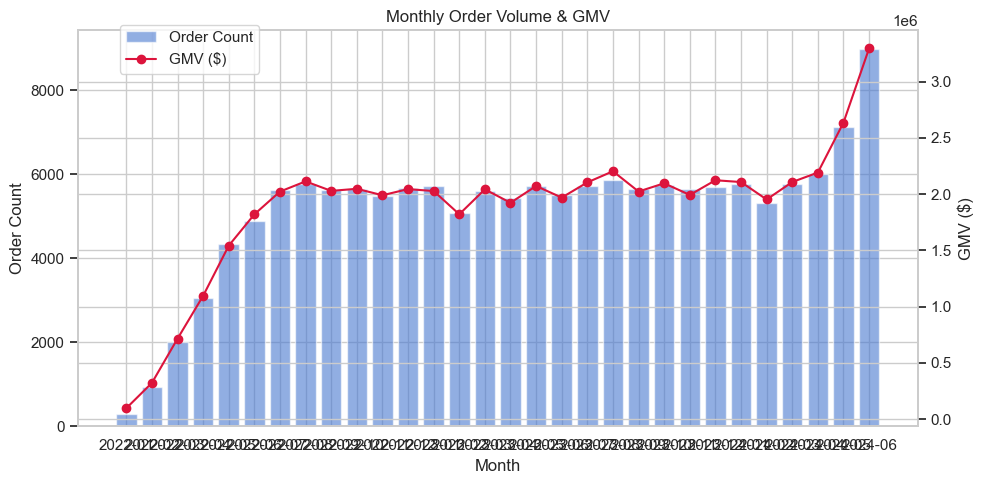

,order_month,order_count,gmv
0,2022-01,302,97736.60
1,2022-02,932,322923.39
2,2022-03,2005,715746.82
3,2022-04,3054,1096502.27
4,2022-05,4332,1542294.17
5,2022-06,4891,1820655.28
6,2022-07,5639,2023049.84
7,2022-08,5762,2113577.92
8,2022-09,5623,2029178.44
9,2022-10,5647,2047746.11


In [3]:
df_gmv = query("""
    WITH cleaned AS (
        SELECT order_id,
               CAST(REPLACE(REPLACE(order_amount, '$', ''), ',', '') AS REAL) AS amt,
               SUBSTR(order_date, 1, 7) AS order_month
        FROM   orders
        WHERE  order_date IS NOT NULL
    )
    SELECT order_month,
           COUNT(*)        AS order_count,
           ROUND(SUM(CASE WHEN amt > 0 AND amt < 50000 THEN amt ELSE 0 END), 2) AS gmv
    FROM   cleaned
    GROUP  BY order_month
    ORDER  BY order_month
""")

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.bar(df_gmv["order_month"], df_gmv["order_count"], alpha=0.6, label="Order Count")
ax2.plot(df_gmv["order_month"], df_gmv["gmv"], color="crimson", marker="o", label="GMV ($)")
ax1.set_xlabel("Month")
ax1.set_ylabel("Order Count")
ax2.set_ylabel("GMV ($)")
ax1.set_title("Monthly Order Volume & GMV")
plt.xticks(rotation=45)
fig.legend(loc="upper left", bbox_to_anchor=(0.12, 0.95))
plt.tight_layout()
plt.show()

df_gmv

### Payment plan distribution

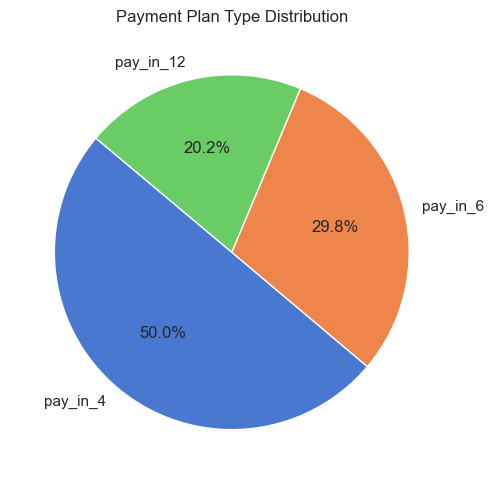

,plan_type,plan_count,avg_installments,avg_apr
0,pay_in_4,69153,4.0,0.00
1,pay_in_6,41293,6.0,0.10
2,pay_in_12,27974,12.0,0.15


In [4]:
df_plans = query("""
    SELECT plan_type,
           COUNT(*)                              AS plan_count,
           ROUND(AVG(num_installments), 1)       AS avg_installments,
           ROUND(AVG(apr), 2)                    AS avg_apr
    FROM   payment_plans
    GROUP  BY plan_type
    ORDER  BY plan_count DESC
""")

fig, ax = plt.subplots()
ax.pie(df_plans["plan_count"], labels=df_plans["plan_type"], autopct="%1.1f%%", startangle=140)
ax.set_title("Payment Plan Type Distribution")
plt.tight_layout()
plt.show()

df_plans

### Approval vs decline rates

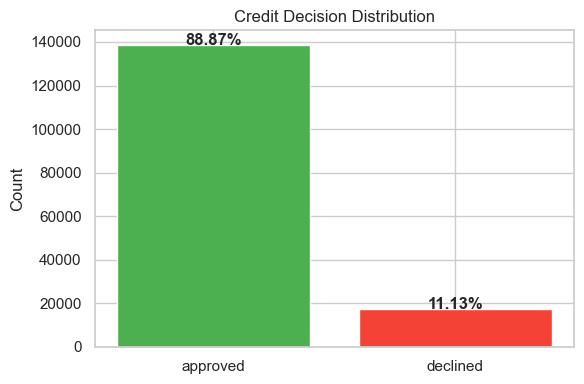

,decision,total,pct
0,approved,138420,88.87
1,declined,17330,11.13


In [5]:
df_decisions = query("""
    SELECT decision,
           COUNT(*)                                             AS total,
           ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM credit_decisions), 2) AS pct
    FROM   credit_decisions
    GROUP  BY decision
    ORDER  BY total DESC
""")

fig, ax = plt.subplots(figsize=(6, 4))
colors = {"approved": "#4CAF50", "declined": "#F44336"}
bars = ax.bar(df_decisions["decision"], df_decisions["total"],
              color=[colors.get(d.lower(), "#999") for d in df_decisions["decision"]])
for bar, pct in zip(bars, df_decisions["pct"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
            f"{pct}%", ha="center", fontweight="bold")
ax.set_title("Credit Decision Distribution")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

df_decisions

### Order status breakdown

In [6]:
df_status = query("""
    SELECT order_status,
           COUNT(*) AS order_count
    FROM   orders
    GROUP  BY order_status
    ORDER  BY order_count DESC
""")

df_status

,order_status,order_count
0,completed,128565
1,declined,17330
2,defaulted,9855


## JOINs and Aggregations

### Delinquency by merchant category

An installment is "delinquent" if `days_past_due > 0`. We JOIN through orders → payment_plans → installments to tie installments back to merchant categories.

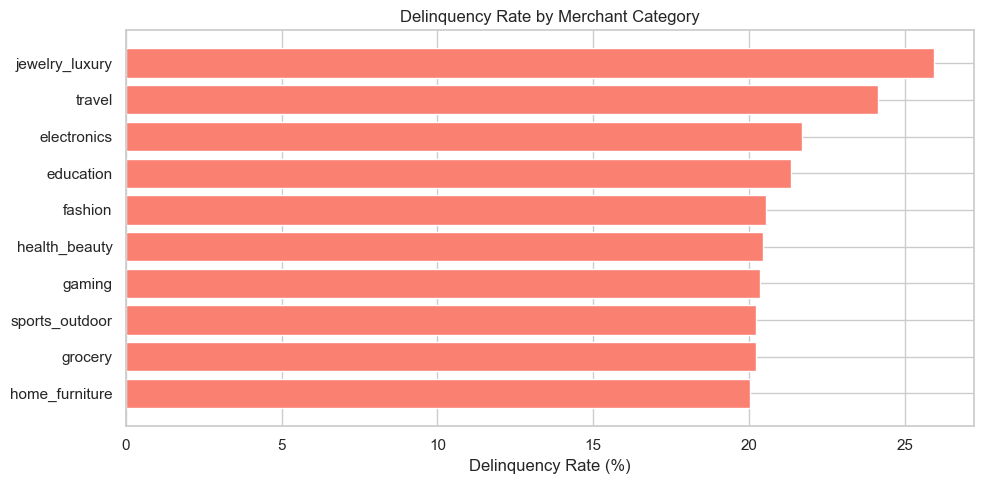

,category,total_installments,delinquent,delinquency_pct
0,jewelry_luxury,46193,11971,25.92
1,travel,72075,17404,24.15
2,electronics,173845,37749,21.71
3,education,25777,5502,21.34
4,fashion,209081,42925,20.53
5,health_beauty,101676,20805,20.46
6,gaming,58221,11844,20.34
7,sports_outdoor,42585,8617,20.23
8,grocery,41537,8404,20.23
9,home_furniture,84768,16979,20.03


In [7]:
df_delinq = query("""
    SELECT m.category,
           COUNT(i.installment_id)                                          AS total_installments,
           SUM(CASE WHEN i.days_past_due > 0 THEN 1 ELSE 0 END)           AS delinquent,
           ROUND(SUM(CASE WHEN i.days_past_due > 0 THEN 1 ELSE 0 END)
                 * 100.0 / COUNT(i.installment_id), 2)                     AS delinquency_pct
    FROM   merchants m
           JOIN orders o        ON m.merchant_id = o.merchant_id
           JOIN payment_plans p ON o.order_id    = p.order_id
           JOIN installments i  ON p.plan_id     = i.plan_id
    GROUP  BY m.category
    ORDER  BY delinquency_pct DESC
""")

fig, ax = plt.subplots()
ax.barh(df_delinq["category"][::-1], df_delinq["delinquency_pct"][::-1], color="salmon")
ax.set_xlabel("Delinquency Rate (%)")
ax.set_title("Delinquency Rate by Merchant Category")
plt.tight_layout()
plt.show()

df_delinq

### Average DPD by plan type

In [8]:
df_dpd = query("""
    SELECT p.plan_type,
           ROUND(AVG(i.days_past_due), 1) AS avg_dpd,
           ROUND(MAX(i.days_past_due), 0) AS max_dpd,
           COUNT(i.installment_id)         AS installment_count
    FROM   payment_plans p
           JOIN installments i ON p.plan_id = i.plan_id
    WHERE  i.days_past_due IS NOT NULL
    GROUP  BY p.plan_type
    ORDER  BY avg_dpd DESC
""")

df_dpd

,plan_type,avg_dpd,max_dpd,installment_count
0,pay_in_4,8.6,149.0,275243
1,pay_in_6,8.4,149.0,246511
2,pay_in_12,8.2,149.0,334004


### Merchants with highest dispute rates

In [9]:
df_dispute = query("""
    SELECT m.merchant_name,
           m.category,
           COUNT(DISTINCT o.order_id)                            AS total_orders,
           COUNT(DISTINCT d.dispute_id)                          AS disputes,
           ROUND(COUNT(DISTINCT d.dispute_id) * 100.0
                 / COUNT(DISTINCT o.order_id), 2)                AS dispute_rate_pct
    FROM   merchants m
           JOIN orders o   ON m.merchant_id = o.merchant_id
           LEFT JOIN disputes d ON o.order_id = d.order_id
    GROUP  BY m.merchant_id, m.merchant_name, m.category
    HAVING COUNT(DISTINCT o.order_id) >= 50
    ORDER  BY dispute_rate_pct DESC
    LIMIT  10
""")

df_dispute

,merchant_name,category,total_orders,disputes,dispute_rate_pct
0,Apex Gadgets,electronics,278,24,8.63
1,Max Luxury,jewelry_luxury,338,27,7.99
2,Value Care,health_beauty,414,33,7.97
3,Peak Devices,electronics,312,24,7.69
4,Super Apparel,fashion,286,22,7.69
5,Nova Gems,jewelry_luxury,318,24,7.55
6,Value Luxury,jewelry_luxury,306,23,7.52
7,NextGen Bijoux,jewelry_luxury,321,24,7.48
8,Classic Electronics,electronics,336,25,7.44
9,Smart Decor,home_furniture,260,19,7.31


### Payment success by method

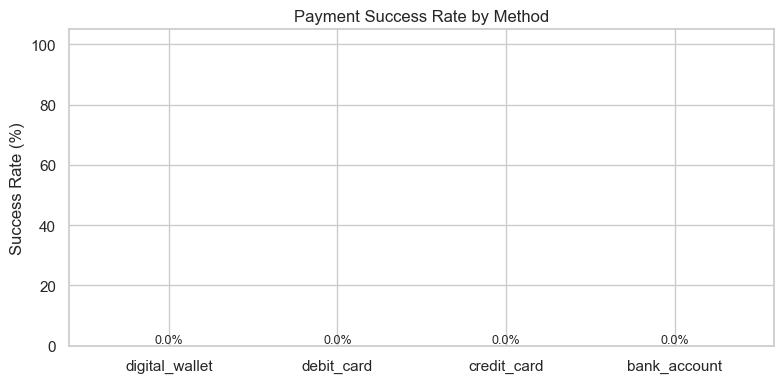

,payment_method,total_payments,successful,success_rate_pct
0,digital_wallet,93148,0,0.0
1,debit_card,217017,0,0.0
2,credit_card,154245,0,0.0
3,bank_account,154639,0,0.0


In [10]:
df_payment = query("""
    SELECT payment_method,
           COUNT(*)                                                        AS total_payments,
           SUM(CASE WHEN LOWER(payment_status) = 'completed' THEN 1 ELSE 0 END) AS successful,
           ROUND(SUM(CASE WHEN LOWER(payment_status) = 'completed' THEN 1 ELSE 0 END)
                 * 100.0 / COUNT(*), 2)                                    AS success_rate_pct
    FROM   payments
    GROUP  BY payment_method
    ORDER  BY success_rate_pct DESC
""")

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(df_payment["payment_method"], df_payment["success_rate_pct"], color="steelblue")
ax.set_ylabel("Success Rate (%)")
ax.set_title("Payment Success Rate by Method")
ax.set_ylim(0, 105)
for i, (method, rate) in enumerate(zip(df_payment["payment_method"], df_payment["success_rate_pct"])):
    ax.text(i, rate + 1, f"{rate}%", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

df_payment

### Order size by employment status

In [11]:
df_emp = query("""
    SELECT c.employment_status,
           COUNT(o.order_id) AS order_count,
           ROUND(AVG(
               CASE
                   WHEN CAST(REPLACE(REPLACE(o.order_amount, '$', ''), ',', '') AS REAL)
                        BETWEEN 0 AND 50000
                   THEN CAST(REPLACE(REPLACE(o.order_amount, '$', ''), ',', '') AS REAL)
               END
           ), 2) AS avg_order_amount
    FROM   customers c
           JOIN orders o ON c.customer_id = o.customer_id
    WHERE  c.employment_status IS NOT NULL
    GROUP  BY c.employment_status
    ORDER  BY avg_order_amount DESC
""")

df_emp

,employment_status,order_count,avg_order_amount
0,self_employed,17937,370.70
1,retired,7706,367.32
2,unemployed,11630,364.65
3,employed_full_time,74527,363.95
4,student,15296,363.75
5,employed_part_time,22630,363.44


## Window Functions

### Order sequence with running total

For each customer, number their orders chronologically and compute a cumulative spend.

In [12]:
df_seq = query("""
    WITH cleaned_orders AS (
        SELECT customer_id,
               order_id,
               order_date,
               CAST(REPLACE(REPLACE(order_amount, '$', ''), ',', '') AS REAL) AS amt
        FROM   orders
        WHERE  CAST(REPLACE(REPLACE(order_amount, '$', ''), ',', '') AS REAL) BETWEEN 0 AND 50000
    )
    SELECT customer_id,
           order_id,
           order_date,
           ROUND(amt, 2) AS order_amount,
           ROW_NUMBER() OVER (PARTITION BY customer_id ORDER BY order_date) AS order_seq,
           ROUND(SUM(amt) OVER (PARTITION BY customer_id
                                ORDER BY order_date
                                ROWS UNBOUNDED PRECEDING), 2) AS running_total
    FROM   cleaned_orders
    ORDER  BY customer_id, order_date
    LIMIT  30
""")

df_seq

,customer_id,order_id,order_date,order_amount,order_seq,running_total
0,1,1,2022-12-22T13:31:03,20.00,1,20.00
1,1,2,2023-03-11T10:55:38,118.08,2,138.08
2,1,3,2023-03-18T10:30:43,32.41,3,170.49
3,1,4,2023-03-24T08:28:43,439.68,4,610.17
4,1,5,2023-06-30T09:46:09,121.25,5,731.42
5,2,6,2023-11-20T07:12:28,81.45,1,81.45
6,3,8,2024-01-07T22:58:00,1144.75,1,1144.75
7,3,9,2024-02-09T15:08:41,1381.09,2,2525.84
8,3,7,2024-03-11T18:03:42,121.20,3,2647.04
9,4,11,2024-04-07T21:16:36,1198.71,1,1198.71


### Cohort default rates by signup month

Customers are grouped by their signup month. For each cohort, we track the percentage whose payment plans ended in default.

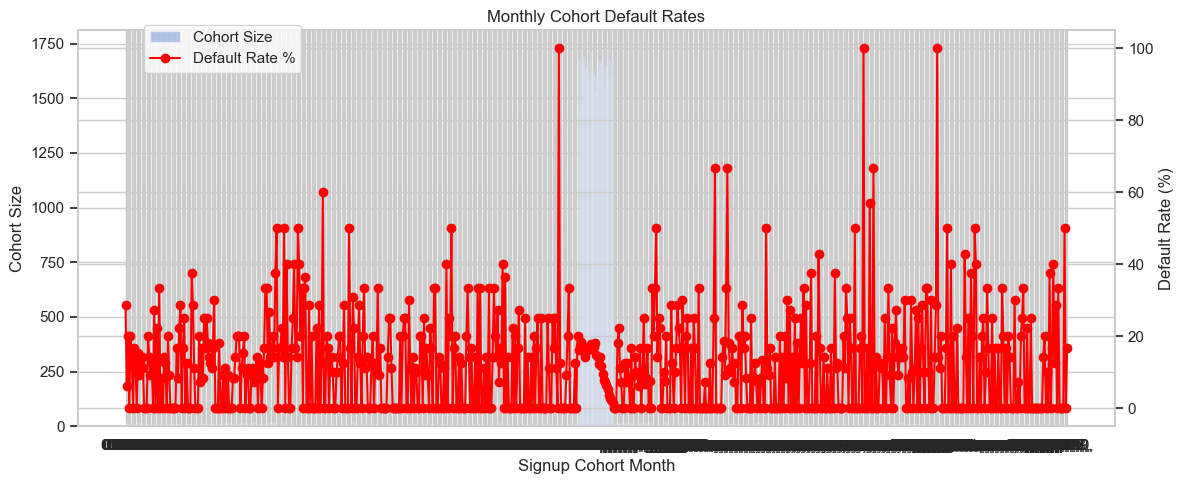

,cohort_month,cohort_size,defaulted_customers,default_rate_pct
0,01/01/2,7,2,28.57
1,01/02/2,16,1,6.25
2,01/03/2,10,2,20.00
3,01/04/2,9,0,0.00
4,01/05/2,5,1,20.00
...,...,...,...,...
750,"Sep 26,",4,0,0.00
751,"Sep 27,",6,0,0.00
752,"Sep 28,",4,2,50.00
753,"Sep 29,",3,0,0.00


In [13]:
df_cohort = query("""
    WITH customer_cohort AS (
        SELECT customer_id,
               SUBSTR(signup_date, 1, 7) AS cohort_month
        FROM   customers
        WHERE  signup_date IS NOT NULL
    )
    SELECT cc.cohort_month,
           COUNT(DISTINCT cc.customer_id)                              AS cohort_size,
           COUNT(DISTINCT CASE WHEN LOWER(pp.plan_status) = 'defaulted'
                               THEN cc.customer_id END)               AS defaulted_customers,
           ROUND(COUNT(DISTINCT CASE WHEN LOWER(pp.plan_status) = 'defaulted'
                                     THEN cc.customer_id END)
                 * 100.0 / COUNT(DISTINCT cc.customer_id), 2)         AS default_rate_pct
    FROM   customer_cohort cc
           LEFT JOIN orders o        ON cc.customer_id = o.customer_id
           LEFT JOIN payment_plans pp ON o.order_id    = pp.order_id
    GROUP  BY cc.cohort_month
    ORDER  BY cc.cohort_month
""")

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()
ax1.bar(df_cohort["cohort_month"], df_cohort["cohort_size"], alpha=0.4, label="Cohort Size")
ax2.plot(df_cohort["cohort_month"], df_cohort["default_rate_pct"],
         color="red", marker="o", label="Default Rate %")
ax1.set_xlabel("Signup Cohort Month")
ax1.set_ylabel("Cohort Size")
ax2.set_ylabel("Default Rate (%)")
ax1.set_title("Monthly Cohort Default Rates")
plt.xticks(rotation=45)
fig.legend(loc="upper left", bbox_to_anchor=(0.12, 0.95))
plt.tight_layout()
plt.show()

df_cohort

### Rolling 3-month volume trend

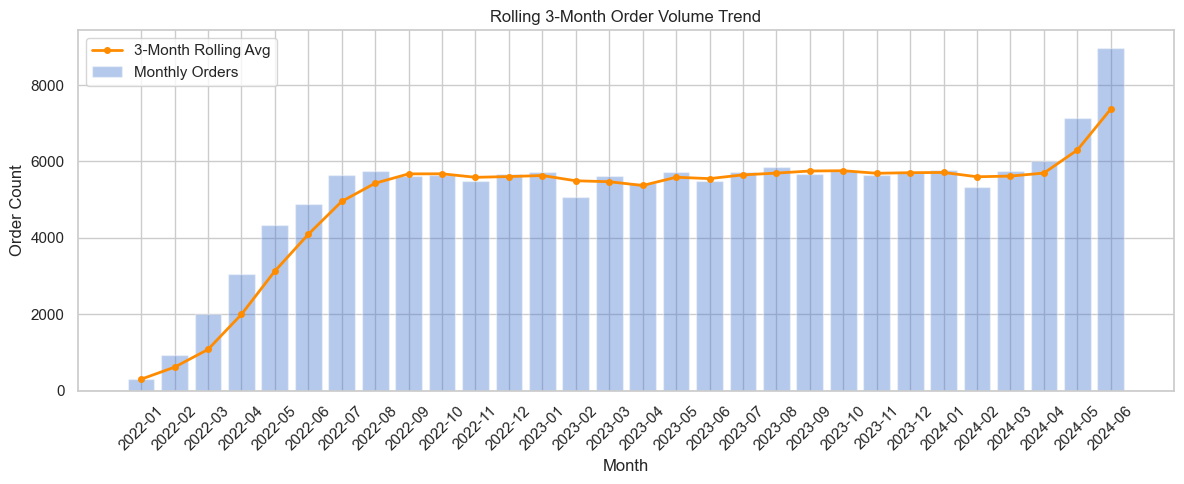

,order_month,order_count,rolling_3m_avg
0,2022-01,302,302.0
1,2022-02,932,617.0
2,2022-03,2005,1079.7
3,2022-04,3054,1997.0
4,2022-05,4332,3130.3
5,2022-06,4891,4092.3
6,2022-07,5639,4954.0
7,2022-08,5762,5430.7
8,2022-09,5623,5674.7
9,2022-10,5647,5677.3


In [14]:
df_rolling = query("""
    WITH monthly AS (
        SELECT SUBSTR(order_date, 1, 7) AS order_month,
               COUNT(*)                 AS order_count
        FROM   orders
        WHERE  order_date IS NOT NULL
        GROUP  BY SUBSTR(order_date, 1, 7)
    )
    SELECT order_month,
           order_count,
           ROUND(AVG(order_count) OVER (
               ORDER BY order_month
               ROWS BETWEEN 2 PRECEDING AND CURRENT ROW
           ), 1) AS rolling_3m_avg
    FROM   monthly
    ORDER  BY order_month
""")

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(df_rolling["order_month"], df_rolling["order_count"], alpha=0.4, label="Monthly Orders")
ax.plot(df_rolling["order_month"], df_rolling["rolling_3m_avg"],
        color="darkorange", linewidth=2, marker="o", markersize=4, label="3-Month Rolling Avg")
ax.set_xlabel("Month")
ax.set_ylabel("Order Count")
ax.set_title("Rolling 3-Month Order Volume Trend")
plt.xticks(rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

df_rolling

### Merchant default ranking within category

Uses `RANK()` with `PARTITION BY` to find the highest-default merchants per category.

In [15]:
df_rank = query("""
    WITH merchant_defaults AS (
        SELECT m.merchant_id,
               m.merchant_name,
               m.category,
               COUNT(DISTINCT pp.plan_id) AS total_plans,
               SUM(CASE WHEN LOWER(pp.plan_status) = 'defaulted' THEN 1 ELSE 0 END) AS defaults,
               ROUND(SUM(CASE WHEN LOWER(pp.plan_status) = 'defaulted' THEN 1 ELSE 0 END)
                     * 100.0 / COUNT(DISTINCT pp.plan_id), 2) AS default_rate_pct
        FROM   merchants m
               JOIN orders o        ON m.merchant_id = o.merchant_id
               JOIN payment_plans pp ON o.order_id   = pp.order_id
        GROUP  BY m.merchant_id, m.merchant_name, m.category
        HAVING COUNT(DISTINCT pp.plan_id) >= 10
    )
    SELECT merchant_name,
           category,
           total_plans,
           defaults,
           default_rate_pct,
           RANK() OVER (PARTITION BY category ORDER BY default_rate_pct DESC) AS rank_in_category
    FROM   merchant_defaults
    ORDER  BY category, rank_in_category
""")

df_rank[df_rank["rank_in_category"] <= 3]

,merchant_name,category,total_plans,defaults,default_rate_pct,rank_in_category
0,Quick Academy,education,349,27,7.74,1
1,NextGen Learning,education,378,29,7.67,2
2,Premier Learning,education,389,25,6.43,3
11,Premier Electronics,electronics,258,41,15.89,1
12,Express Computing,electronics,288,37,12.85,2
13,Peak Devices,electronics,278,32,11.51,3
116,Urban Fashion,fashion,258,30,11.63,1
117,Core Fashion,fashion,265,27,10.19,2
118,Ultra Style,fashion,286,29,10.14,3
245,Smart Games,gaming,263,27,10.27,1


## CTEs and Subqueries

### First Payment Default rate by month

FPD measures the percentage of plans whose **first** installment was missed. This is a key early indicator of credit risk — a high FPD rate suggests the underwriting model is letting through bad applicants.

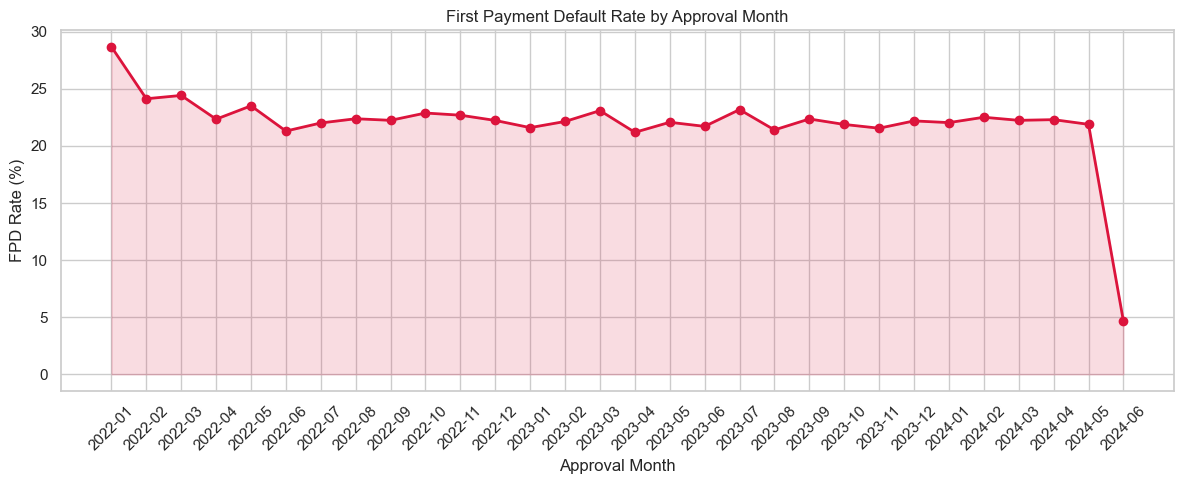

,approval_month,total_plans,fpd_count,fpd_rate_pct
0,2022-01,258,74,28.68
1,2022-02,833,201,24.13
2,2022-03,1777,434,24.42
3,2022-04,2730,610,22.34
4,2022-05,3858,907,23.51
5,2022-06,4310,918,21.30
6,2022-07,5038,1109,22.01
7,2022-08,5142,1151,22.38
8,2022-09,5000,1112,22.24
9,2022-10,5013,1147,22.88


In [16]:
df_fpd = query("""
    WITH first_installment AS (
        SELECT plan_id,
               installment_id,
               status,
               days_past_due,
               ROW_NUMBER() OVER (PARTITION BY plan_id ORDER BY installment_number) AS rn
        FROM   installments
    ),
    fpd AS (
        SELECT fi.plan_id,
               fi.status AS first_installment_status,
               fi.days_past_due,
               SUBSTR(pp.start_date, 1, 7) AS approval_month
        FROM   first_installment fi
               JOIN payment_plans pp ON fi.plan_id = pp.plan_id
        WHERE  fi.rn = 1
          AND  pp.start_date IS NOT NULL
    )
    SELECT approval_month,
           COUNT(*)                                                          AS total_plans,
           SUM(CASE WHEN days_past_due > 0 OR LOWER(first_installment_status) IN ('missed', 'late', 'overdue')
                    THEN 1 ELSE 0 END)                                       AS fpd_count,
           ROUND(SUM(CASE WHEN days_past_due > 0 OR LOWER(first_installment_status) IN ('missed', 'late', 'overdue')
                          THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2)         AS fpd_rate_pct
    FROM   fpd
    GROUP  BY approval_month
    ORDER  BY approval_month
""")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_fpd["approval_month"], df_fpd["fpd_rate_pct"],
        marker="o", color="crimson", linewidth=2)
ax.fill_between(df_fpd["approval_month"], df_fpd["fpd_rate_pct"], alpha=0.15, color="crimson")
ax.set_xlabel("Approval Month")
ax.set_ylabel("FPD Rate (%)")
ax.set_title("First Payment Default Rate by Approval Month")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

df_fpd

### CLV by credit score band

Segments customers into credit score bands and computes their total spend (cleaning dirty `order_amount` values).

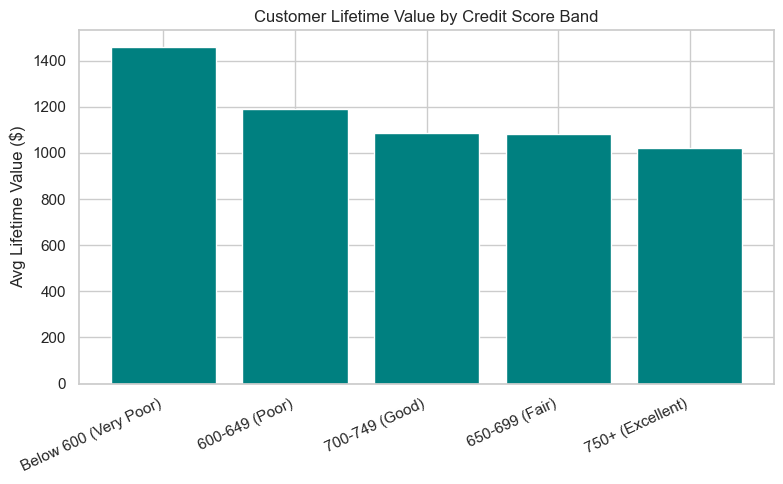

,credit_band,customers,avg_lifetime_value,avg_orders,total_gmv
0,Below 600 (Very Poor),6257,1458.09,3.6,9123282.63
1,600-649 (Poor),5473,1188.20,3.2,6503018.46
2,700-749 (Good),8474,1088.13,3.0,9220771.46
3,650-699 (Fair),10010,1079.71,3.0,10807911.04
4,750+ (Excellent),12217,1021.10,3.0,12474821.78


In [17]:
df_clv = query("""
    WITH cleaned_orders AS (
        SELECT customer_id,
               CAST(REPLACE(REPLACE(order_amount, '$', ''), ',', '') AS REAL) AS amt
        FROM   orders
        WHERE  CAST(REPLACE(REPLACE(order_amount, '$', ''), ',', '') AS REAL) BETWEEN 0 AND 50000
    ),
    customer_spend AS (
        SELECT co.customer_id,
               c.credit_score,
               CASE
                   WHEN c.credit_score >= 750 THEN '750+ (Excellent)'
                   WHEN c.credit_score >= 700 THEN '700-749 (Good)'
                   WHEN c.credit_score >= 650 THEN '650-699 (Fair)'
                   WHEN c.credit_score >= 600 THEN '600-649 (Poor)'
                   ELSE 'Below 600 (Very Poor)'
               END AS credit_band,
               COUNT(*)       AS order_count,
               SUM(co.amt)    AS total_spend
        FROM   cleaned_orders co
               JOIN customers c ON co.customer_id = c.customer_id
        WHERE  c.credit_score IS NOT NULL
        GROUP  BY co.customer_id, c.credit_score
    )
    SELECT credit_band,
           COUNT(*)                        AS customers,
           ROUND(AVG(total_spend), 2)      AS avg_lifetime_value,
           ROUND(AVG(order_count), 1)      AS avg_orders,
           ROUND(SUM(total_spend), 2)      AS total_gmv
    FROM   customer_spend
    GROUP  BY credit_band
    ORDER  BY avg_lifetime_value DESC
""")

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(df_clv["credit_band"], df_clv["avg_lifetime_value"], color="teal")
ax.set_ylabel("Avg Lifetime Value ($)")
ax.set_title("Customer Lifetime Value by Credit Score Band")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

df_clv

### Repeat defaulters

Finds customers who defaulted on a plan, later got a **new** plan, and then defaulted **again**. These serial defaulters represent the highest-risk segment.

In [18]:
df_recid = query("""
    WITH customer_plans AS (
        SELECT o.customer_id,
               pp.plan_id,
               pp.start_date,
               pp.plan_status,
               ROW_NUMBER() OVER (PARTITION BY o.customer_id ORDER BY pp.start_date) AS plan_seq
        FROM   orders o
               JOIN payment_plans pp ON o.order_id = pp.order_id
        WHERE  pp.start_date IS NOT NULL
    ),
    defaults_with_next AS (
        SELECT cp1.customer_id,
               cp1.plan_id          AS first_default_plan,
               cp1.start_date       AS first_default_date,
               cp2.plan_id          AS subsequent_plan,
               cp2.start_date       AS subsequent_date,
               cp2.plan_status      AS subsequent_status
        FROM   customer_plans cp1
               JOIN customer_plans cp2
                 ON cp1.customer_id = cp2.customer_id
                AND cp2.plan_seq    > cp1.plan_seq
        WHERE  LOWER(cp1.plan_status) = 'defaulted'
    )
    SELECT customer_id,
           COUNT(DISTINCT first_default_plan)  AS default_count,
           COUNT(DISTINCT subsequent_plan)     AS plans_after_first_default,
           SUM(CASE WHEN LOWER(subsequent_status) = 'defaulted' THEN 1 ELSE 0 END) AS re_defaults
    FROM   defaults_with_next
    GROUP  BY customer_id
    HAVING re_defaults > 0
    ORDER  BY re_defaults DESC
    LIMIT  20
""")

print(f"Found {len(df_recid)} repeat defaulters (showing top 20)")
df_recid

Found 20 repeat defaulters (showing top 20)


,customer_id,default_count,plans_after_first_default,re_defaults
0,49754,6,6,21
1,49218,6,6,21
2,48407,6,6,21
3,48176,6,6,21
4,46860,6,6,21
5,45032,6,6,21
6,44326,6,6,21
7,40109,6,6,21
8,34893,6,6,21
9,29356,6,6,21


### Fraud ring detection via shared devices

Identifies clusters of customers sharing the same `device_id` or `ip_address` (from `device_fingerprints`) who also have elevated default rates. Shared devices among defaulting customers are a strong fraud signal.

In [19]:
df_rings_device = query("""
    WITH device_sharing AS (
        SELECT device_id,
               COUNT(DISTINCT customer_id) AS customers_sharing
        FROM   device_fingerprints
        WHERE  device_id IS NOT NULL
        GROUP  BY device_id
        HAVING COUNT(DISTINCT customer_id) > 1
    ),
    shared_device_customers AS (
        SELECT df.device_id,
               df.customer_id,
               ds.customers_sharing
        FROM   device_fingerprints df
               JOIN device_sharing ds ON df.device_id = ds.device_id
    ),
    customer_defaults AS (
        SELECT o.customer_id,
               COUNT(DISTINCT pp.plan_id) AS total_plans,
               SUM(CASE WHEN LOWER(pp.plan_status) = 'defaulted' THEN 1 ELSE 0 END) AS defaults
        FROM   orders o
               JOIN payment_plans pp ON o.order_id = pp.order_id
        GROUP  BY o.customer_id
    )
    SELECT sdc.device_id,
           sdc.customers_sharing,
           GROUP_CONCAT(DISTINCT sdc.customer_id) AS customer_ids,
           SUM(cd.defaults)                        AS total_defaults_in_cluster,
           SUM(cd.total_plans)                     AS total_plans_in_cluster,
           ROUND(SUM(cd.defaults) * 100.0 / SUM(cd.total_plans), 2) AS cluster_default_rate_pct
    FROM   shared_device_customers sdc
           LEFT JOIN customer_defaults cd ON sdc.customer_id = cd.customer_id
    GROUP  BY sdc.device_id, sdc.customers_sharing
    HAVING cluster_default_rate_pct > 30
    ORDER  BY cluster_default_rate_pct DESC, customers_sharing DESC
    LIMIT  15
""")

print(f"Suspicious device clusters (default rate > 30%): {len(df_rings_device)}")
df_rings_device

Suspicious device clusters (default rate > 30%): 6


,device_id,customers_sharing,customer_ids,total_defaults_in_cluster,total_plans_in_cluster,cluster_default_rate_pct
0,SHARED_DEV_9,58,"113,179,513,1080,1104,1420,1668,2054,2572,3353...",102,279,36.56
1,SHARED_DEV_2,76,"454,807,1091,1635,3337,3660,5710,5897,5969,605...",112,349,32.09
2,SHARED_DEV_14,74,"246,486,1420,1668,2570,3516,3886,4625,6050,610...",94,296,31.76
3,SHARED_DEV_6,67,"179,246,486,1104,3337,4246,4859,4937,5710,6104...",101,324,31.17
4,SHARED_DEV_8,74,"113,1104,1302,1420,2570,4270,4900,4905,4937,58...",110,355,30.99
5,SHARED_DEV_10,66,"53,1456,3027,3337,5069,7463,7725,8944,10301,11...",97,322,30.12


In [20]:
df_rings_ip = query("""
    WITH ip_sharing AS (
        SELECT ip_address,
               COUNT(DISTINCT customer_id) AS customers_sharing
        FROM   device_fingerprints
        WHERE  ip_address IS NOT NULL
        GROUP  BY ip_address
        HAVING COUNT(DISTINCT customer_id) > 1
    ),
    shared_ip_customers AS (
        SELECT df.ip_address,
               df.customer_id,
               ips.customers_sharing
        FROM   device_fingerprints df
               JOIN ip_sharing ips ON df.ip_address = ips.ip_address
    ),
    customer_defaults AS (
        SELECT o.customer_id,
               COUNT(DISTINCT pp.plan_id) AS total_plans,
               SUM(CASE WHEN LOWER(pp.plan_status) = 'defaulted' THEN 1 ELSE 0 END) AS defaults
        FROM   orders o
               JOIN payment_plans pp ON o.order_id = pp.order_id
        GROUP  BY o.customer_id
    )
    SELECT sic.ip_address,
           sic.customers_sharing,
           GROUP_CONCAT(DISTINCT sic.customer_id) AS customer_ids,
           SUM(cd.defaults)                        AS total_defaults_in_cluster,
           SUM(cd.total_plans)                     AS total_plans_in_cluster,
           ROUND(SUM(cd.defaults) * 100.0 / SUM(cd.total_plans), 2) AS cluster_default_rate_pct
    FROM   shared_ip_customers sic
           LEFT JOIN customer_defaults cd ON sic.customer_id = cd.customer_id
    GROUP  BY sic.ip_address, sic.customers_sharing
    HAVING cluster_default_rate_pct > 30
    ORDER  BY customers_sharing DESC, cluster_default_rate_pct DESC
    LIMIT  15
""")

print(f"Suspicious IP clusters (default rate > 30%): {len(df_rings_ip)}")
df_rings_ip

Suspicious IP clusters (default rate > 30%): 4


,ip_address,customers_sharing,customer_ids,total_defaults_in_cluster,total_plans_in_cluster,cluster_default_rate_pct
0,163.218.28.243,94,"359,365,807,1080,1302,2054,2572,3516,3886,4051...",131,424,30.90
1,144.30.204.118,88,"1019,1091,2572,3353,3886,4559,4905,5040,5683,5...",145,471,30.79
2,207.39.209.98,77,"486,1080,2821,3027,4858,5279,6733,6921,7219,10...",117,365,32.05
3,184.124.112.173,73,"359,578,1019,1302,1456,5763,5962,6150,6935,746...",98,326,30.06


## Takeaways

### Key Findings from the SQL Analysis

**Data Quality:**
- `order_amount` contains dollar-sign strings and outlier values; all monetary queries use `REPLACE`/`CAST` with a `0–50 000` sanity range.
- Some `installments` reference orphaned `plan_id`s — defensive `JOIN`s prevent silent row loss.

**Portfolio Health:**
- Credit decision approval rates and order status distributions provide the baseline for how selective the underwriting model is.
- Payment plan type distribution shows which BNPL products are most popular and their associated APRs.

**Risk Signals:**
- **Delinquency by merchant category** reveals which verticals carry the highest installment-level delinquency, informing merchant risk tiering.
- **First Payment Default (FPD)** is the earliest signal of credit deterioration. Tracking FPD by approval month exposes whether underwriting quality is improving or degrading over time.
- **Cohort default rates** show whether newer customer vintages perform better or worse than older ones — critical for vintage-based loss forecasting.

**Fraud Detection:**
- **Recidivism analysis** identified customers who defaulted, were re-approved, and defaulted again — a gap in the re-approval policy.
- **Fraud ring detection** surfaced clusters of customers sharing the same physical device or IP address with elevated default rates. These clusters warrant manual review and potential account linking rules.

### Recommended Next Steps
1. **Tighten re-approval logic** for customers with prior defaults (recidivism findings).
2. **Implement device/IP velocity checks** to flag applications from known fraud-ring clusters at decisioning time.
3. **Monitor FPD rate monthly** as an early warning system; set an alert threshold (e.g., > 10%).
4. **Review merchant risk tiers** for categories with delinquency rates above the portfolio average.
5. **Build predictive features** from the signals above (shared devices, FPD history, credit band) for a machine-learning fraud model.

In [21]:
conn.close()